# Regressão Multi-Output: 48 Itens RIASEC → Big Five (TIPI)
Dataset público com 145 k respondentes. Features: 48 itens RIASEC individuais (R1–R8, I1–I8, A1–A8, S1–S8, E1–E8, C1–C8) + dados demográficos.  
Targets: 5 traços Big Five derivados da escala TIPI (reversão de itens).  
Modelo: ExtraTrees + RandomizedSearchCV.


In [1]:
# Imports
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    KFold, RandomizedSearchCV, cross_validate, train_test_split
)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import Bunch
import scipy.stats as st

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 60)


## Leitura e limpeza dos dados


In [2]:
DATA_PATH = Path('../RIASEC/data.csv')
assert DATA_PATH.exists(), f'Ficheiro não encontrado: {DATA_PATH}'

df_raw = pd.read_csv(DATA_PATH, sep='\t', low_memory=False)
print('Shape bruto:', df_raw.shape)
df_raw.head(3)


Shape bruto: (145828, 94)


,R1,R2,R3,R4,R5,R6,R7,R8,I1,I2,I3,I4,I5,I6,I7,I8,A1,A2,A3,A4,A5,A6,A7,A8,S1,S2,S3,S4,S5,S6,...,VCL4,VCL5,VCL6,VCL7,VCL8,VCL9,VCL10,VCL11,VCL12,VCL13,VCL14,VCL15,VCL16,education,urban,gender,engnat,age,hand,religion,orientation,race,voted,married,familysize,uniqueNetworkLocation,country,source,major,Unnamed: 93
0,3,4,3,1,1,4,1,3,5,5,4,3,4,5,4,3,5,4,1,2,4,5,2,4,3,5,5,4,5,5,...,1,1,0,0,0,0,1,0,0,1,1,1,1,2,2,1,1,14,1,7,1,1,2,1,1,1,US,2,NaN,NaN
1,1,1,2,4,1,2,2,1,5,5,5,4,4,4,4,4,2,1,4,2,1,3,4,2,2,3,4,3,4,2,...,1,1,0,1,0,0,1,0,0,1,1,1,1,2,2,1,1,29,1,7,3,4,1,2,3,1,US,1,Nursing,NaN
2,2,1,1,1,1,1,1,1,4,1,1,1,1,1,1,1,1,1,1,2,1,1,3,1,3,1,5,3,5,5,...,1,1,0,0,0,0,1,0,0,0,0,1,1,2,1,2,1,23,1,7,1,4,2,1,1,1,US,1,NaN,NaN


In [4]:
# Limpeza
df = df_raw.copy()

# Remover coluna vazia extra
df = df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')], errors='ignore')

# Filtrar respondentes inválidos: assinalaram palavras falsas VCL6, VCL9 ou VCL12
invalid_vcl = (df['VCL6'] == 1) | (df['VCL9'] == 1) | (df['VCL12'] == 1)
print(f'Removidos por VCL falsos: {invalid_vcl.sum()}')
df = df[~invalid_vcl]

# Remover idades inválidas (< 13 já foi feito na origem; filtrar também > 100 e 0)
df['age'] = pd.to_numeric(df['age'], errors='coerce')
age_mask = df['age'].between(13, 100)
print(f'Removidos por idade inválida: {(~age_mask).sum()}')
df = df[age_mask]

# Remover linhas onde todos os itens RIASEC são 0 (não respondeu)
riasec_items = [f'{d}{i}' for d in 'RIASEC' for i in range(1, 9)]
all_zero = (df[riasec_items] == 0).all(axis=1)
print(f'Removidos por itens RIASEC todos zero: {all_zero.sum()}')
df = df[~all_zero]

# Remover linhas onde todos os itens TIPI são 0
tipi_items = [f'TIPI{i}' for i in range(1, 11)]
tipi_zero = (df[tipi_items] == 0).all(axis=1)
print(f'Removidos por TIPI todos zero: {tipi_zero.sum()}')
df = df[~tipi_zero]

print(f'\nShape limpo: {df.shape}')


Removidos por VCL falsos: 29285
Removidos por idade inválida: 58
Removidos por itens RIASEC todos zero: 40
Removidos por TIPI todos zero: 463

Shape limpo: (115982, 93)


## Derivação dos targets Big Five a partir do TIPI

Fórmula de reversão (escala 1–7):
- **Extraversão**: (TIPI1 + (8 − TIPI6)) / 2
- **Amabilidade**: ((8 − TIPI2) + TIPI7) / 2
- **Conscienciosidade**: (TIPI3 + (8 − TIPI8)) / 2
- **Neuroticismo**: (TIPI4 + (8 − TIPI9)) / 2
- **Abertura**: (TIPI5 + (8 − TIPI10)) / 2


,mean,std,min,max
big5_extraversion,4.088160,1.629448,0.5,7.5
big5_agreeableness,4.852865,1.238923,0.5,7.5
big5_conscientiousness,5.210317,1.400939,0.5,7.5
big5_neuroticism,3.567959,1.514252,0.5,7.5
big5_openness,5.389953,1.188807,0.5,7.5


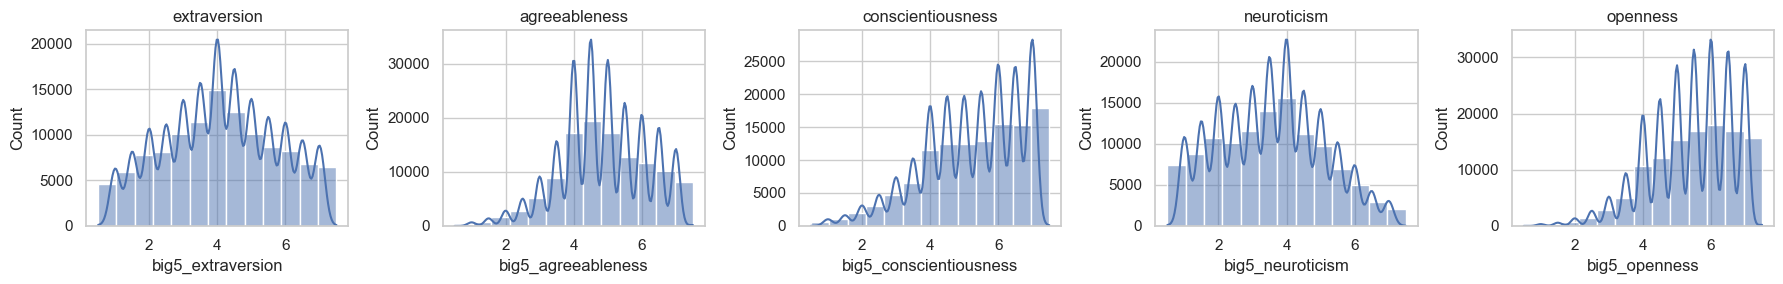

In [5]:
# Calcular scores Big Five via reversão TIPI
df['big5_extraversion']       = (df['TIPI1'] + (8 - df['TIPI6']))  / 2
df['big5_agreeableness']      = ((8 - df['TIPI2']) + df['TIPI7'])  / 2
df['big5_conscientiousness']  = (df['TIPI3'] + (8 - df['TIPI8']))  / 2
df['big5_neuroticism']        = (df['TIPI4'] + (8 - df['TIPI9']))  / 2
df['big5_openness']           = (df['TIPI5'] + (8 - df['TIPI10'])) / 2

target_cols = [
    'big5_extraversion', 'big5_agreeableness', 'big5_conscientiousness',
    'big5_neuroticism', 'big5_openness'
]

# Remover linhas com targets nulos
df = df.dropna(subset=target_cols)

# Distribuição dos targets
target_stats = df[target_cols].agg(['mean', 'std', 'min', 'max'])
display(target_stats.T)

fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=False)
for ax, col in zip(axes, target_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax, bins=13)
    ax.set_title(col.replace('big5_', ''))
plt.tight_layout()
plt.show()


## Engenharia de features e definição de X / y


In [6]:
# Features: 48 itens RIASEC + scores agregados por dimensão + demográficos
riasec_items = [f'{d}{i}' for d in 'RIASEC' for i in range(1, 9)]

# Scores médios por dimensão RIASEC (sinal mais compacto)
for dim in 'RIASEC':
    cols = [f'{dim}{i}' for i in range(1, 9)]
    df[f'score_{dim}'] = df[cols].mean(axis=1)

score_cols = [f'score_{d}' for d in 'RIASEC']

# Features demográficas numéricas/categóricas
demo_num  = ['age', 'familysize']
demo_cat  = ['education', 'urban', 'gender', 'engnat', 'hand',
             'religion', 'orientation', 'race', 'voted', 'married']

# Vocabulário: número de palavras reais assinaladas (VCL sem as falsas)
vcl_real = [f'VCL{i}' for i in [1,2,3,4,5,7,8,10,11,13,14,15,16]]
df['vcl_score'] = df[vcl_real].sum(axis=1)

feature_cols = riasec_items + score_cols + demo_num + demo_cat + ['vcl_score']

y = df[target_cols].copy()
X = df[feature_cols].copy()

# Para as categóricas demo: converter para string (OHE irá tratar nulos)
for c in demo_cat:
    X[c] = X[c].astype('Int64').astype(str).replace('<NA>', np.nan)

print('X shape:', X.shape)
print('y shape:', y.shape)
X.dtypes


X shape: (115982, 67)
y shape: (115982, 5)


R1             int64
R2             int64
R3             int64
R4             int64
R5             int64
               ...  
orientation      str
race             str
voted            str
married          str
vcl_score      int64
Length: 67, dtype: object

In [7]:
# Split treino/teste estratificado por género
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('Treino:', X_train.shape, '  Teste:', X_test.shape)


Treino: (92785, 67)   Teste: (23197, 67)


## Pipeline de pré-processamento + modelo base


In [8]:
# Recalcular listas de colunas a partir de X (mantém sincronizado)
_cat_cols = sorted([c for c in X.columns if X[c].dtype == object])
_num_cols = [c for c in X.columns if c not in _cat_cols]

print('Categóricas:', _cat_cols)
print('Numéricas  :', _num_cols)

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, _cat_cols),
    ('num', num_pipeline, _num_cols),
])

et_base_reg = ExtraTreesRegressor(
    n_estimators=300, max_depth=None, min_samples_leaf=1,
    n_jobs=-1, random_state=42
)

model = Pipeline([
    ('prep', preprocessor),
    ('clf',  MultiOutputRegressor(et_base_reg))
])
model


Categóricas: []
Numéricas  : ['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'score_R', 'score_I', 'score_A', 'score_S', 'score_E', 'score_C', 'age', 'familysize', 'education', 'urban', 'gender', 'engnat', 'hand', 'religion', 'orientation', 'race', 'voted', 'married', 'vcl_score']


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

## Validação cruzada (5-fold) — modelo base ET


In [10]:

scoring = {
    'mae':  'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2':   'r2'
}
# 3 folds em vez de 5 → menos fits; estimator com n_jobs=1 para evitar
# paralelismo aninhado (cross_validate já usa n_jobs=-1 no outer loop)
cv = KFold(n_splits=3, shuffle=True, random_state=42)

cv_model = Pipeline([
    ('prep', preprocessor),
    ('clf',  MultiOutputRegressor(
        ExtraTreesRegressor(
            n_estimators=100,   # reduzido de 300 → suficiente para estimativa
            max_depth=None,
            min_samples_leaf=1,
            n_jobs=1,           # evita paralelismo aninhado com o outer n_jobs
            random_state=42
        )
    ))
])

cv_results = cross_validate(
    cv_model, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False
)

cv_summary = {
    'MAE_mean':  -cv_results['test_mae'].mean(),
    'MAE_std':    cv_results['test_mae'].std(),
    'RMSE_mean': -cv_results['test_rmse'].mean(),
    'RMSE_std':   cv_results['test_rmse'].std(),
    'R2_mean':    cv_results['test_r2'].mean(),
    'R2_std':     cv_results['test_r2'].std(),
}
print('CV (3-fold) — ET base (100 trees):')
cv_summary


CV (3-fold) — ET base (100 trees):


c:\Users\user\Documents\Github\riasec-ml\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
2 fits failed out of a total of 3.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\user\Documents\Github\riasec-ml\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\user\Documents\Github\riasec-ml\.venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\user\Documents\Github\riasec-ml\.venv\L

{'MAE_mean': np.float64(nan),
 'MAE_std': np.float64(nan),
 'RMSE_mean': np.float64(nan),
 'RMSE_std': np.float64(nan),
 'R2_mean': np.float64(nan),
 'R2_std': np.float64(nan)}

In [11]:
# Baseline DummyRegressor
dummy_pipe = Pipeline([
    ('prep',  preprocessor),
    ('dummy', MultiOutputRegressor(DummyRegressor(strategy='mean')))
])
dummy_pipe.fit(X_train, y_train)
y_dummy = pd.DataFrame(dummy_pipe.predict(X_test), columns=target_cols, index=X_test.index)

baseline_metrics = {}
for col in target_cols:
    baseline_metrics[col] = {
        'MAE':  mean_absolute_error(y_test[col], y_dummy[col]),
        'RMSE': np.sqrt(mean_squared_error(y_test[col], y_dummy[col])),
        'R2':   r2_score(y_test[col], y_dummy[col])
    }

baseline_df = pd.DataFrame(baseline_metrics).T
print('Baseline Dummy:')
display(baseline_df)
baseline_overall = {
    'MAE_macro':  baseline_df['MAE'].mean(),
    'RMSE_macro': baseline_df['RMSE'].mean(),
    'R2_macro':   baseline_df['R2'].mean()
}
baseline_overall


Baseline Dummy:


,MAE,RMSE,R2
big5_extraversion,1.338722,1.623083,-0.000001
big5_agreeableness,1.001711,1.235749,-0.000139
big5_conscientiousness,1.164127,1.393578,-0.000025
big5_neuroticism,1.250926,1.517752,-0.000093
big5_openness,0.970961,1.184195,-0.000057


{'MAE_macro': np.float64(1.1452894291860591),
 'RMSE_macro': np.float64(1.3908712854365177),
 'R2_macro': np.float64(-6.305570780362757e-05)}

## Tuning — RandomizedSearchCV ExtraTrees


In [13]:

from sklearn.base import clone

et_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf',  MultiOutputRegressor(ExtraTreesRegressor(random_state=42, n_jobs=1)))
])

param_dist = {
    'clf__estimator__n_estimators':    [100, 150, 200],
    'clf__estimator__max_depth':       [5, 8, 12, None],
    'clf__estimator__min_samples_leaf':[1, 2, 3],
    'clf__estimator__max_features':    ['sqrt', 'log2', 0.3],
}

# Subsample para o tuning: 30 k linhas (~25% do treino)
TUNE_SAMPLE = 30_000
if len(X_train) > TUNE_SAMPLE:
    idx = np.random.default_rng(42).choice(len(X_train), size=TUNE_SAMPLE, replace=False)
    X_tune = X_train.iloc[idx]
    y_tune = y_train.iloc[idx]
    print(f'Subsample para tuning: {X_tune.shape} (de {X_train.shape})')
else:
    X_tune, y_tune = X_train, y_train
    print('Dataset pequeno — usando treino completo para tuning')

et_search = RandomizedSearchCV(
    et_pipe,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring=scoring,
    refit='r2',
    n_jobs=1,
    random_state=42,
    verbose=2
)

print('Rodando RandomizedSearchCV para ExtraTrees...')
et_search.fit(X_tune, y_tune)
print('Melhor R² (cv):', et_search.best_score_)
print('Melhores params:', et_search.best_params_)

# Clonar o pipeline com os melhores params e retreinar no treino completo
best_et: Pipeline = clone(et_pipe).set_params(**et_search.best_params_)
print('\nRetreinando no treino completo com os melhores params...')
best_et.fit(X_train, y_train)
print('Retreino concluído.')


Subsample para tuning: (30000, 67) (de (92785, 67))
Rodando RandomizedSearchCV para ExtraTrees...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END clf__estimator__max_depth=12, clf__estimator__max_features=0.3, clf__estimator__min_samples_leaf=2, clf__estimator__n_estimators=200; total time=  40.8s
[CV] END clf__estimator__max_depth=12, clf__estimator__max_features=0.3, clf__estimator__min_samples_leaf=2, clf__estimator__n_estimators=200; total time=  39.3s
[CV] END clf__estimator__max_depth=12, clf__estimator__max_features=0.3, clf__estimator__min_samples_leaf=2, clf__estimator__n_estimators=200; total time=  37.8s
[CV] END clf__estimator__max_depth=5, clf__estimator__max_features=log2, clf__estimator__min_samples_leaf=1, clf__estimator__n_estimators=150; total time=   4.2s
[CV] END clf__estimator__max_depth=5, clf__estimator__max_features=log2, clf__estimator__min_samples_leaf=1, clf__estimator__n_estimators=150; total time=   4.2s
[CV] END clf__estimator__max_de

## Avaliação hold-out e comparação de modelos


In [15]:

def eval_model(estimator, X_te: pd.DataFrame, y_te: pd.DataFrame, label: str) -> dict:
    y_hat = pd.DataFrame(estimator.predict(X_te), columns=target_cols, index=X_te.index)
    per_trait = {}
    for col in target_cols:
        per_trait[col] = {
            'MAE':  mean_absolute_error(y_te[col], y_hat[col]),
            'RMSE': np.sqrt(mean_squared_error(y_te[col], y_hat[col])),
            'R2':   r2_score(y_te[col], y_hat[col])
        }
    macro = {
        'MAE_macro':  np.mean([v['MAE']  for v in per_trait.values()]),
        'RMSE_macro': np.mean([v['RMSE'] for v in per_trait.values()]),
        'R2_macro':   np.mean([v['R2']   for v in per_trait.values()])
    }
    print(f'\n== {label} ==')
    display(pd.DataFrame(per_trait).T.round(4))
    print('Macro:', {k: round(v, 4) for k, v in macro.items()})
    return macro

# Modelo base: mesmo subsample do tuning para evitar OOM (comparação justa)
model_base = Pipeline([
    ('prep', preprocessor),
    ('clf',  MultiOutputRegressor(
        ExtraTreesRegressor(n_estimators=200, max_depth=12,
                            min_samples_leaf=1, n_jobs=1, random_state=42)
    ))
])
print('Treinando ET base no subsample...')
model_base.fit(X_tune, y_tune)

et_base_macro  = eval_model(model_base, X_test, y_test, 'ET base (subsample, sem tuning)')
et_tuned_macro = eval_model(best_et,    X_test, y_test, 'ET tuned (treino completo)')

summary_compare = pd.DataFrame([
    {'model': 'Baseline Dummy',  **baseline_overall},
    {'model': 'ET base',         **et_base_macro},
    {'model': 'ET tuned',        **et_tuned_macro},
])
print('\n=== Comparação final ===')
summary_compare


Treinando ET base no subsample...

== ET base (subsample, sem tuning) ==


,MAE,RMSE,R2
big5_extraversion,1.2354,1.5005,0.1453
big5_agreeableness,0.9308,1.1510,0.1323
big5_conscientiousness,1.0490,1.2822,0.1535
big5_neuroticism,1.1855,1.4392,0.1007
big5_openness,0.8669,1.0801,0.1681


Macro: {'MAE_macro': np.float64(1.0535), 'RMSE_macro': np.float64(1.2906), 'R2_macro': np.float64(0.14)}

== ET tuned (treino completo) ==


,MAE,RMSE,R2
big5_extraversion,1.2404,1.5038,0.1416
big5_agreeableness,0.9325,1.1514,0.1317
big5_conscientiousness,1.0543,1.2828,0.1526
big5_neuroticism,1.1877,1.4399,0.0999
big5_openness,0.8663,1.0781,0.1711


Macro: {'MAE_macro': np.float64(1.0562), 'RMSE_macro': np.float64(1.2912), 'R2_macro': np.float64(0.1394)}

=== Comparação final ===


,model,MAE_macro,RMSE_macro,R2_macro
0,Baseline Dummy,1.145289,1.390871,-0.000063
1,ET base,1.053507,1.290600,0.139982
2,ET tuned,1.056249,1.291217,0.139365


## Importância de features — permutação (ET tuned)


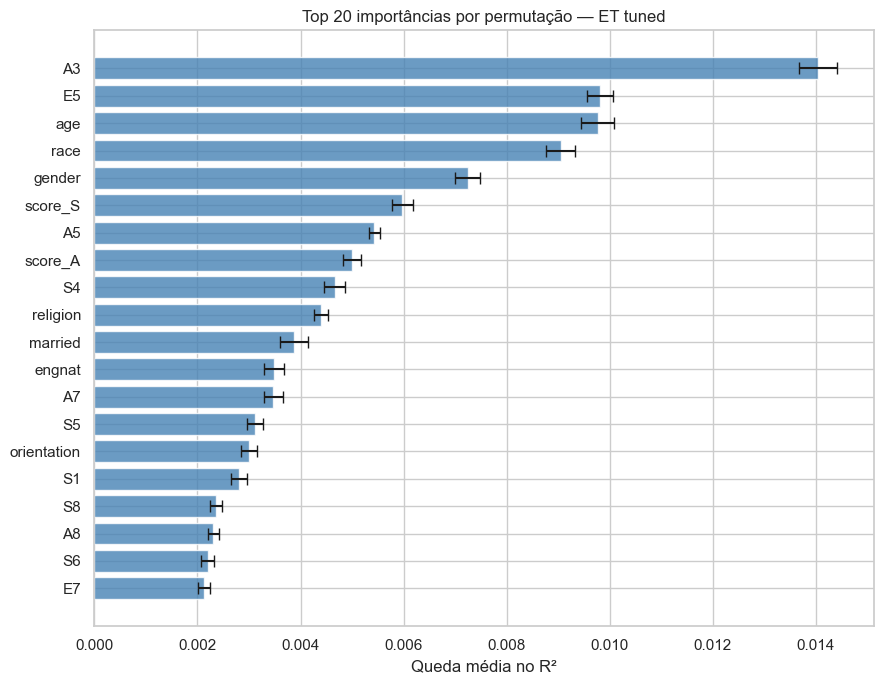

,feature,importance_mean,importance_std
0,A3,0.014034,0.000371
1,E5,0.009805,0.000255
2,age,0.009769,0.000322
3,race,0.009046,0.000274
4,gender,0.007244,0.000238
5,score_S,0.005978,0.000199
6,A5,0.005434,0.000102
7,score_A,0.004994,0.000176
8,S4,0.004663,0.000206
9,religion,0.004398,0.000142


In [17]:

result = permutation_importance(
    best_et, X_test, y_test, n_repeats=10, random_state=42, n_jobs=1
)
assert isinstance(result, Bunch)

imp_mean = result.importances_mean
imp_std  = result.importances_std
if imp_mean.ndim > 1:
    imp_mean = imp_mean.mean(axis=0)
    imp_std  = imp_std.mean(axis=0)

importances = pd.DataFrame({
    'feature':         list(X_test.columns),
    'importance_mean': imp_mean,
    'importance_std':  imp_std
}).sort_values('importance_mean', ascending=False)

topk = importances.head(20).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(
    topk['feature'][::-1],
    topk['importance_mean'][::-1],
    xerr=topk['importance_std'][::-1].values,
    align='center', color='steelblue', alpha=0.8, capsize=4
)
ax.set_title('Top 20 importâncias por permutação — ET tuned')
ax.set_xlabel('Queda média no R²')
plt.tight_layout()
plt.show()
topk


## Salvar modelo


In [20]:
artifacts_dir = Path('models')
artifacts_dir.mkdir(parents=True, exist_ok=True)
model_path = artifacts_dir / 'riasec_tipi_et_tuned.pkl'
joblib.dump(best_et, model_path)
print('Modelo guardado em:', model_path)
model_path


Modelo guardado em: models\riasec_tipi_et_tuned.pkl


WindowsPath('models/riasec_tipi_et_tuned.pkl')